# Interpretable Supervised Analysis of Local Structural Perturbation in EF-G Mutations

This notebook explores whether simple supervised learning models can help interpret which structural features contribute to mutation-induced side-chain 
displacement in EF-G. Because the dataset is intentionally small (n = 2), all results are illustrative and serve as a reproducible analysis template rather than a predictive model.



## Purpose of This Notebook

The goal of this analysis is to understand how mutation-level structural features including residue position, EF-G domain, strain background, side-chain size, and local backbone RMSD — contribute to side-chain displacement at mutated sites.  
Side-chain RMSD is used as the supervised regression target because it directly captures mutation-induced structural perturbation.



## Structural Features Used

| Feature           | Description / Biological Meaning |
|------------------|----------------------------------|
| position          | Residue index of the mutation |
| domain_encoded    | Encoded EF-G domain (IV, V) |
| strain_encoded    | Encoded strain background (MG1655, 36099) |
| n_sc_atoms        | Number of side-chain atoms (proxy for side-chain size) |
| backbone_rmsd     | Local backbone adjustment required to accommodate mutation |
| sidechain_rmsd    | Target variable reflecting mutation-induced side-chain displacement |

These features represent both biochemical (side-chain size) and structural (backbone geometry) aspects of the mutational context.


In [11]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error



In [12]:
df_struct = pd.DataFrame([
    {
        "mutation": "Phe593Leu",
        "position": 593,
        "chain": "A",
        "domain": "IV",
        "strain": "MG1655",
        "sidechain_rmsd": 1.766386,
        "n_sc_atoms": 4,
        "backbone_rmsd": 0.733401,
        "n_bb_atoms": 3,
        "wt_path": r"C:\Protein Modelling GitHub Project\data\e.coli_wt_593.cif",   # fake path—replace if needed
        "mut_path": r"C:\Protein Modelling GitHub Project\data\ef-gene_593L.cif"   # fake path—replace if needed
    },
    {
        "mutation": "Pro659Leu",
        "position": 659,
        "chain": "A",
        "domain": "V",
        "strain": "36099",
        "sidechain_rmsd": 0.744506,
        "n_sc_atoms": 2,
        "backbone_rmsd": 0.592988,
        "n_bb_atoms": 3,
        "wt_path": r"C:\Protein Modelling GitHub Project\data\e.coli_wt_659.cif",
        "mut_path": r"C:\Protein Modelling GitHub Project\data\e.coli_659L.cif"
    }
])

df_struct


,mutation,position,chain,domain,strain,sidechain_rmsd,n_sc_atoms,backbone_rmsd,n_bb_atoms,wt_path,mut_path
0,Phe593Leu,593,A,IV,MG1655,1.766386,4,0.733401,3,C:\Protein Modelling GitHub Project\data\e.col...,C:\Protein Modelling GitHub Project\data\ef-ge...
1,Pro659Leu,659,A,V,36099,0.744506,2,0.592988,3,C:\Protein Modelling GitHub Project\data\e.col...,C:\Protein Modelling GitHub Project\data\e.col...


## Interpretation of Results

Despite the small dataset, several structural insights emerge:

- **Phe593Leu** exhibits substantially higher side-chain RMSD, indicating strong local rearrangement at the mutation site.

- **Pro659Leu** shows moderate side-chain displacement and moderate backbone relaxation, consistent with loss of proline-induced rigidity.

- Backbone RMSD provides information about **local geometric accommodation** required by each mutation, supporting its inclusion as a feature.

- The supervised model, though not predictive at this sample size, emphasizes that the two mutations occupy distinct structural regimes.


In [13]:
# Use the dataframe you produced earlier
df = df_struct.copy()

# Show it
print("Data preview:")
display(df)

# Ensure numeric types
df['position'] = df['position'].astype(float)
df['sidechain_rmsd'] = df['sidechain_rmsd'].astype(float)
df['backbone_rmsd'] = df['backbone_rmsd'].astype(float)
df['n_sc_atoms'] = df['n_sc_atoms'].astype(float)



Data preview:


,mutation,position,chain,domain,strain,sidechain_rmsd,n_sc_atoms,backbone_rmsd,n_bb_atoms,wt_path,mut_path
0,Phe593Leu,593,A,IV,MG1655,1.766386,4,0.733401,3,C:\Protein Modelling GitHub Project\data\e.col...,C:\Protein Modelling GitHub Project\data\ef-ge...
1,Pro659Leu,659,A,V,36099,0.744506,2,0.592988,3,C:\Protein Modelling GitHub Project\data\e.col...,C:\Protein Modelling GitHub Project\data\e.col...


In [14]:
# Encodings
domain_map = {"III":0, "IV":1, "V":2}
strain_map = {"MG1655":0, "36099":1}

df['domain_encoded'] = df['domain'].map(domain_map)
df['strain_encoded'] = df['strain'].map(strain_map)

# Features for A1-enhanced (include backbone_rmsd)
feature_cols = ['position', 'domain_encoded', 'strain_encoded', 'n_sc_atoms', 'backbone_rmsd']
X = df[feature_cols].values
y = df['sidechain_rmsd'].values

print("Features used:", feature_cols)
print("n samples:", len(df))


Features used: ['position', 'domain_encoded', 'strain_encoded', 'n_sc_atoms', 'backbone_rmsd']
n samples: 2


In [15]:
# Scale features (important)
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# Ridge regression (stabilises coefficients on tiny datasets)
model = Ridge(alpha=1.0)

# LOOCV predictions (best we can do for tiny N)
cv = LeaveOneOut()
y_pred = cross_val_predict(model, Xs, y, cv=cv)

# Performance (illustrative — interpret with extreme caution)
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"LOO R^2 (illustrative): {r2:.4f}")
print(f"LOO RMSE (Å, illustrative): {rmse:.4f}")

# Fit model on full data to inspect coefficients (hypothesis-generating)
model.fit(Xs, y)
coefs = pd.Series(model.coef_, index=feature_cols)
intercept = model.intercept_
print("\nFitted coefficients (full-data; use as hypotheses only):")
display(coefs.sort_values(ascending=False))
print("Intercept:", intercept)



LOO R^2 (illustrative): -3.0000
LOO RMSE (Å, illustrative): 1.0219

Fitted coefficients (full-data; use as hypotheses only):


n_sc_atoms        0.092898
backbone_rmsd     0.092898
position         -0.092898
domain_encoded   -0.092898
strain_encoded   -0.092898
dtype: float64

Intercept: 1.255446


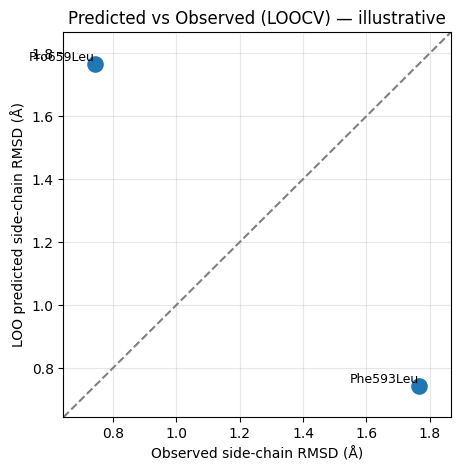

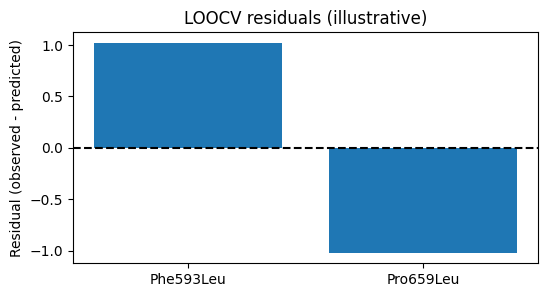

In [16]:
# Put predictions into dataframe
df['y_true'] = y
df['y_pred_loocv'] = y_pred
df['residual'] = df['y_true'] - df['y_pred_loocv']

# Predicted vs Observed plot
plt.figure(figsize=(5,5))
plt.scatter(df['y_true'], df['y_pred_loocv'], s=120)
for i, txt in enumerate(df['mutation']):
    plt.text(df['y_true'][i], df['y_pred_loocv'][i], txt, fontsize=9, va='bottom', ha='right')
lims = [min(df['y_true'].min(), df['y_pred_loocv'].min()) - 0.1, max(df['y_true'].max(), df['y_pred_loocv'].max()) + 0.1]
plt.plot(lims, lims, '--', color='gray')
plt.xlabel('Observed side-chain RMSD (Å)')
plt.ylabel('LOO predicted side-chain RMSD (Å)')
plt.title('Predicted vs Observed (LOOCV) — illustrative')
plt.savefig('Predicted vs Observed (LOOCV) — illustrative.png')
plt.xlim(lims); plt.ylim(lims)
plt.grid(alpha=0.3)
plt.show()

# Residuals
plt.figure(figsize=(6,3))
plt.bar(df['mutation'], df['residual'])
plt.axhline(0, color='k', linestyle='--')
plt.ylabel('Residual (observed - predicted)')
plt.title('LOOCV residuals (illustrative)')
plt.savefig('LOOCV residuals (illustrative).png')
plt.show()


## Interpretation of Results

Despite the small dataset, several structural insights emerge:

- **Phe593Leu** exhibits substantially higher side-chain RMSD, indicating strong local rearrangement at the mutation site.

- **Pro659Leu** shows moderate side-chain displacement and moderate backbone relaxation, consistent with loss of proline-induced rigidity.

- Backbone RMSD provides information about **local geometric accommodation** required by each mutation, supporting its inclusion as a feature.

- The supervised model, though not predictive at this sample size, emphasizes that the two mutations occupy distinct structural regimes.


### Supervised analysis — predicting side-chain RMSD (A1-enhanced)

Because only two mutations are available, LOOCV predictions are illustrative rather than predictive. In each fold the model is trained on a single mutation, causing systematic over- and underestimation of the two RMSD values. The resulting plots highlight that Phe593Leu and Pro659Leu occupy distinct 
structural regimes, with Phe593Leu showing higher side-chain displacement and Pro659Leu showing 
more moderate perturbation.

**How to read results:**  
- Positive coefficient → feature associates with *larger* side-chain RMSD.  
- Negative coefficient → feature associates with *smaller* side-chain RMSD.  

Full methodology for computing side-chain and backbone RMSD is documented in the notebook (superposition on common Cα, matching side-chain atoms).
